# Testing OgataQuadrature Python Bindings

This notebook demonstrates how to use the OgataQuadrature class from the APFEL++ library through its Python bindings. We'll test all the methods that have been exposed to Python.

## Import the module

First, we need to import the apfelpy module. Note that this assumes the module has been properly built and installed.

In [1]:
# Import the apfelpy module
try:
    import apfelpy
    print("Successfully imported apfelpy module")
except ImportError:
    print("Failed to import apfelpy. Make sure it's properly built and installed.")

Successfully imported apfelpy module


## Create an OgataQuadrature instance

Let's create an instance of the OgataQuadrature class with default parameters.

In [2]:
# Create an OgataQuadrature instance with default parameters
try:
    ogata = apfelpy.ogata.OgataQuadrature()
    print("Successfully created OgataQuadrature instance with default parameters")
except Exception as e:
    print(f"Error creating OgataQuadrature instance: {e}")

Successfully created OgataQuadrature instance with default parameters


Now let's create another instance with custom parameters.

In [3]:
# Create an OgataQuadrature instance with custom parameters
try:
    ogata_custom = apfelpy.ogata.OgataQuadrature(nu=1, CutOff=1e-6, h=0.002, nZeroMax=500)
    print("Successfully created OgataQuadrature instance with custom parameters")
except Exception as e:
    print(f"Error creating OgataQuadrature instance with custom parameters: {e}")

Successfully created OgataQuadrature instance with custom parameters


## Test getter methods

Let's test all the getter methods to verify they work correctly.

In [4]:
# Test getter methods
try:
    print(f"Bessel Order: {ogata_custom.GetBesselOrder()}")
    print(f"Cut Off: {ogata_custom.GetCutOff()}")
    print(f"Step Parameter: {ogata_custom.GetStepParameter()}")
    
    # Get coordinates and weights (these might be large arrays)
    coords = ogata_custom.GetCoordinates()
    weights = ogata_custom.GetWeights()
    
    print(f"Coordinates length: {len(coords)}")
    print(f"First 5 coordinates: {coords[:5]}")
    
    print(f"Weights length: {len(weights)}")
    print(f"First 5 weights: {weights[:5]}")
    
except Exception as e:
    print(f"Error testing getter methods: {e}")

Bessel Order: 1.0
Cut Off: 1e-06
Step Parameter: 0.002
Coordinates length: 500
First 5 coordinates: [0.014681913349463036, 0.04921781247498985, 0.10349660683486754, 0.17751239131362315, 0.27126209543781915]
Weights length: 500
First 5 weights: [0.00018101151347686638, 0.0010925261660272364, 0.003315099276507563, 0.007415870516937495, 0.013924631763442786]


## Test InitialiseWeights method

Let's test the InitialiseWeights method.

In [5]:
# Test InitialiseWeights method
try:
    # Get the initial length of weights
    initial_weights_len = len(ogata.GetWeights())
    print(f"Initial weights length: {initial_weights_len}")
    
    # Reinitialize with a different number
    ogata.InitialiseWeights(500)
    
    # Get the new length of weights
    new_weights_len = len(ogata.GetWeights())
    print(f"New weights length after reinitialization: {new_weights_len}")
    
except Exception as e:
    print(f"Error testing InitialiseWeights method: {e}")

Initial weights length: 1000
New weights length after reinitialization: 1000


## Test SetStepParameter method

Let's test the SetStepParameter method.

In [6]:
# Test SetStepParameter method
try:
    # Get the initial step parameter
    initial_step = ogata.GetStepParameter()
    print(f"Initial step parameter: {initial_step}")
    
    # Set a new step parameter
    new_step = 0.005
    ogata.SetStepParameter(new_step)
    
    # Get the new step parameter
    updated_step = ogata.GetStepParameter()
    print(f"Updated step parameter: {updated_step}")
    
    # Verify it was updated correctly
    assert updated_step == new_step, "Step parameter was not updated correctly"
    print("Step parameter was updated successfully")
    
except Exception as e:
    print(f"Error testing SetStepParameter method: {e}")

Initial step parameter: 0.001
Updated step parameter: 0.005
Step parameter was updated successfully


## Test transform method

Let's test the transform method with a simple function.

In [7]:
# Import numpy for mathematical functions
import numpy as np
import math

# Test transform method with a simple function
try:
    # Define a simple function to transform
    def simple_function(x):
        return math.exp(-x)
    
    # Apply the transform
    qT = 1.0
    result = ogata.transform(simple_function, qT)
    print(f"Transform result for exp(-x) at qT={qT}: {result}")
    
    # Try with different parameters
    qT = 2.0
    result_dynamic = ogata.transform(simple_function, qT, True, 500, 5)
    print(f"Transform result with dynamic h at qT={qT}: {result_dynamic}")
    
    result_static = ogata.transform(simple_function, qT, False, 500, 5)
    print(f"Transform result with static h at qT={qT}: {result_static}")
    
except Exception as e:
    print(f"Error testing transform method: {e}")

Transform result for exp(-x) at qT=1.0: 0.7071067811863072
Transform result with dynamic h at qT=2.0: 0.4472155017611211
Transform result with static h at qT=2.0: 0.4472155017611211


## Test JnuZerosGenerator method

Let's test the JnuZerosGenerator method. Note that this method writes to screen rather than returning a value.
At the moment it seems that within apfelxx that function is not available, but that's not an issue of the python binding, as far as I understand.

In [8]:
# Test JnuZerosGenerator method
try:
    # This method writes to screen, so we'll just call it
    print("Calling JnuZerosGenerator(0) to generate zeros of J0...")
    ogata.JnuZerosGenerator(0)
    print("JnuZerosGenerator method called successfully")
    
except Exception as e:
    print(f"Error testing JnuZerosGenerator method: {e}")

Calling JnuZerosGenerator(0) to generate zeros of J0...
JnuZerosGenerator method called successfully


[apfel::JnuZerosGenerator] Error: Function currently unavailable.



# Plots and testing the Ogata quadrature method in python

The Hankel transform of order ν of a function f(r) is defined as:

$$F(k) = \int_0^{\infty} f(r) J_{\nu}(kr) r dr$$

Where:

- $J_{\nu}$ is the Bessel function of the first kind, of order ν
- $r$ is the input variable
- $k$ is the output variable ($q_T$ in our case)

However, keep in mind that the `c++` in `apfelxx` implementation is:
$$F(k) = \frac{1}{k} \int_0^{\infty} f(r) J_{\nu}(kr) r dr$$

The Ogata quadrature method transforms this infinite integral into a summation by using the zeros of Bessel functions and a clever change of variables. The key insight of the method is to use a transformation that maps the infinite integration range to a finite one, and then apply Gaussian quadrature.

__The Double Exponential (DE) Transformation__

The method uses what's called a "double exponential" transformation:
$$r = \psi(t) = t \tanh(\frac{\pi}{2}\sinh(t))$$

This transformation maps the interval $[0, \infty)$ to $[0, \infty)$ but changes the behavior of the integrand to decay double-exponentially at infinity, which makes numerical integration much more efficient.

__The Quadrature Formula__

After applying this transformation, the Hankel transform becomes:
$$F(k) = \int_0^{\infty} f(\psi(t)) J_{\nu}(k\psi(t)) \psi(t) \psi'(t) dt$$


The Ogata method then uses the zeros of the Bessel function $J_{\nu}$ to create a quadrature formula:
$$F(k) \approx \frac{\pi}{2k} \sum_{j=1}^{N} w_j f(\frac{j_{\nu,j}}{k})$$

Where:
- $j_{\nu,j}$ are the zeros of the Bessel function $J_{\nu}$
- $w_j$ are weights derived from these zeros
- $N$ is the number of terms in the summation


## Effect of the parameter $h$

The parameter $h$ impacets where the zeros of the Bessel function land.

In other words, $h$ is “stretching” or “compressing” the underlying Ogata mesh. 
Here’s what is plotted and how to read it: the horizontal axis is the zero‐index i (so $i=0,1,2, \dots $), the vertical axis is the unscaled coordinate $x_{f,i}$

Each curve is a different choice of h:

- For very small $h$, $(0.0001, 0.001)$, the blue/orange curves climb so slowly that even at $i=200$ you’re barely out of $x<20$. That means all your r‐nodes (which are rᵢ=x{f,i}/q_T_) lie extremely close to zero. So if there is a function that is non-zero in a domain where $x>20$, the quadrature never “sees” the bulk of such function.

- For huge $h$ (here 1.0, the red curve), $x{f,i}$ grows almost perfectly linearly $(\sim \pi \cdot i)$, so your first node is already at $x\simeq 0$, the second at $x \simeq 3.14$, third at $6.28$, etc. --- so you completely skip the region between 0 and 3 (again potentially missing the hump).

- In between (e.g. h=0.01, the green curve) you get a nice smooth “S‐shaped” growth: slow near i=0 (sampling around x≲1), then accelerating so you cover the tail at larger x.

What to conclude:

If your h is too small, the mesh is compressed near r=0 and never samples out where the Gaussian is non‐negligible.
If your h is too large, the mesh is too coarse near the origin and you “jump” over the main hump.

We want an $h$ that gives you a moderate S‐curve so that the first few nodes sit under the Gaussian peak (0≲r≲2) and successive nodes march steadily into its tail.

## Test with a known Hankel transform

Let's test the transform method with a function that has a known analytical Hankel transform.
$$F(k) = \frac{1}{k} \int_0^{\infty} f(r) J_{\nu}(kr) r dr$$

In our example, we're using a Gaussian function:
$$f(r) = e^{-r^2}$$

So we are computing the integral:

(1) $$F(k) = \frac{1}{k} \int_0^{\infty} e^{-r^2} J_{\nu}(kr) r dr$$

The Hankel transform of this Gaussian has a known analytical solution:
$$F(k) = \frac{1}{2}e^{-\frac{k^2}{4}}$$

Therefore, we know the analytical result of:
$$F(k) = \frac{1}{k} \int_0^{\infty} e^{-r^2} J_{\nu}(kr) r dr = \frac{1}{2k}e^{-k^2/4}$$

__GOAL__
Compare the numerical result from OgataQuadrature used on the integral (1)

with the analytical result $\frac{1}{2q_T}e^{-\frac{qT^2}{4}}$.

In [9]:
# Enhanced imports and function definitions
import math
import numpy as np
import matplotlib.pyplot as plt
from apfelpy.ogata import OgataQuadrature  # type: ignore

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# CORRECT TEST FUNCTIONS (matching ogata_test.cc)
# APFEL++ computes: F(k) = (1/k) * ∫₀^∞ f(r) J_ν(kr) r dr

# Test function from C++ test: f(r) = r * exp(-a²r²/2) with a=1
def rfunc_cpp_test(r):
    """The integrand from the C++ test: r * exp(-r²/2)"""
    return r * math.exp(-r*r/2)

# Analytical result: F(k) = exp(-k²/2)/a² with a=1
def kfunc_cpp_test(k):
    """Analytical transform for the C++ test function"""
    return math.exp(-k*k/2)

# ADDITIONAL TEST FUNCTIONS FOR COMPARISON

# Simple Gaussian: f(r) = exp(-r²)
def fr_gaussian(r):
    return math.exp(-r*r)

# For f(r) = exp(-r²), the Hankel transform H[f](k) = (1/2)*exp(-k²/4)
# Since APFEL++ computes F(k) = H[f](k)/k, we have:
def Fk_gaussian_correct(k):
    return 0.5 * math.exp(-k*k/4) / k

# Exponential decay: f(r) = exp(-r)  
def fr_exponential(r):
    return math.exp(-r)

# For f(r) = exp(-r), the Hankel transform H[f](k) = 1/(1+k²)
# Since APFEL++ computes F(k) = H[f](k)/k, we have:
def Fk_exponential_correct(k):
    return 1.0 / (k * (1 + k*k))

print("✅ Functions defined correctly to match APFEL++ implementation")
print("Main test function: f(r) = r * exp(-r²/2)")
print("Analytical result: F(k) = exp(-k²/2)")


✅ Functions defined correctly to match APFEL++ implementation
Main test function: f(r) = r * exp(-r²/2)
Analytical result: F(k) = exp(-k²/2)


## Main Accuracy Test (from ogata_test.cc)

Now let's implement the exact same test as in the C++ `ogata_test.cc` file. This test uses:

**Test function**: $f(r) = r \cdot e^{-r^2/2}$

**Analytical result**: $F(k) = e^{-k^2/2}$

This is the standard test case used in APFEL++ to validate the Ogata quadrature implementation. The test:
1. Uses the same function as the C++ reference implementation
2. Compares numerical results with known analytical solutions
3. Tests accuracy across a wide range of $k$ values
4. Provides a direct comparison with the C++ results


In [10]:
# Main accuracy test (exact copy of ogata_test.cc logic)
def run_cpp_accuracy_test():
    """
    Replicate the exact accuracy test from ogata_test.cc
    """
    # Create Ogata quadrature object (default parameters like C++)
    ogata_obj = OgataQuadrature()
    
    # Test k values (same as C++)
    k_values = [0.0001, 0.001, 0.1, 0.2, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
    
    print("🔬 ACCURACY TEST (replicating ogata_test.cc)")
    print("=" * 80)
    print(f"{'k':>10} {'Analytical':>15} {'Numerical':>15} {'Rel. Error (%)':>15} {'Ratio':>10}")
    print("-" * 80)
    
    numerical_results = []
    analytical_results = []
    relative_errors = []
    ratios = []
    
    for k in k_values:
        # Compute analytical result
        analytical = kfunc_cpp_test(k)
        
        # Compute numerical result (using dynamic h and 50 terms like C++)
        numerical = ogata_obj.transform(rfunc_cpp_test, k, True, 50)
        
        # Compute relative error and ratio
        rel_error = abs(numerical - analytical) / abs(analytical) * 100
        ratio = numerical / analytical
        
        # Store results
        numerical_results.append(numerical)
        analytical_results.append(analytical)
        relative_errors.append(rel_error)
        ratios.append(ratio)
        
        # Print results (matching C++ format)
        print(f"{k:>10.4f} {analytical:>15.6e} {numerical:>15.6e} {rel_error:>15.6f} {ratio:>10.6f}")
    
    print("=" * 80)
    print(f"📊 SUMMARY:")
    print(f"   Average relative error: {np.mean(relative_errors):.6f}%")
    print(f"   Maximum relative error: {np.max(relative_errors):.6f}%")
    print(f"   Minimum relative error: {np.min(relative_errors):.6f}%")
    print(f"   Average ratio: {np.mean(ratios):.6f}")
    print(f"   Ratio std dev: {np.std(ratios):.6f}")
    
    # Check if all errors are reasonable (< 1%)
    max_acceptable_error = 1.0  # 1%
    if np.max(relative_errors) < max_acceptable_error:
        print(f"✅ ALL TESTS PASSED! (All errors < {max_acceptable_error}%)")
    else:
        failing_indices = [i for i, err in enumerate(relative_errors) if err >= max_acceptable_error]
        print(f"❌ Some tests have large errors:")
        for i in failing_indices:
            print(f"   k={k_values[i]}: {relative_errors[i]:.4f}% error")
    
    return k_values, numerical_results, analytical_results, relative_errors, ratios

# Run the C++ accuracy test
k_vals, num_results, ana_results, rel_errors, ratios = run_cpp_accuracy_test()


🔬 ACCURACY TEST (replicating ogata_test.cc)
         k      Analytical       Numerical  Rel. Error (%)      Ratio
--------------------------------------------------------------------------------
    0.0001    1.000000e+00    1.000000e+00        0.000000   1.000000
    0.0010    9.999995e-01    9.999995e-01        0.000000   1.000000
    0.1000    9.950125e-01    9.950125e-01        0.000000   1.000000
    0.2000    9.801987e-01    9.801987e-01        0.000000   1.000000
    0.5000    8.824969e-01    8.824969e-01        0.000000   1.000000
    1.0000    6.065307e-01    6.065307e-01        0.000000   1.000000
    1.5000    3.246525e-01    3.246525e-01        0.000000   1.000000
    2.0000    1.353353e-01    1.353353e-01        0.000000   1.000000
    2.5000    4.393693e-02    4.393693e-02        0.000000   1.000000
    3.0000    1.110900e-02    1.110900e-02        0.000000   1.000000
    4.0000    3.354626e-04    3.354626e-04        0.000000   1.000000
    5.0000    3.726653e-06    3.726

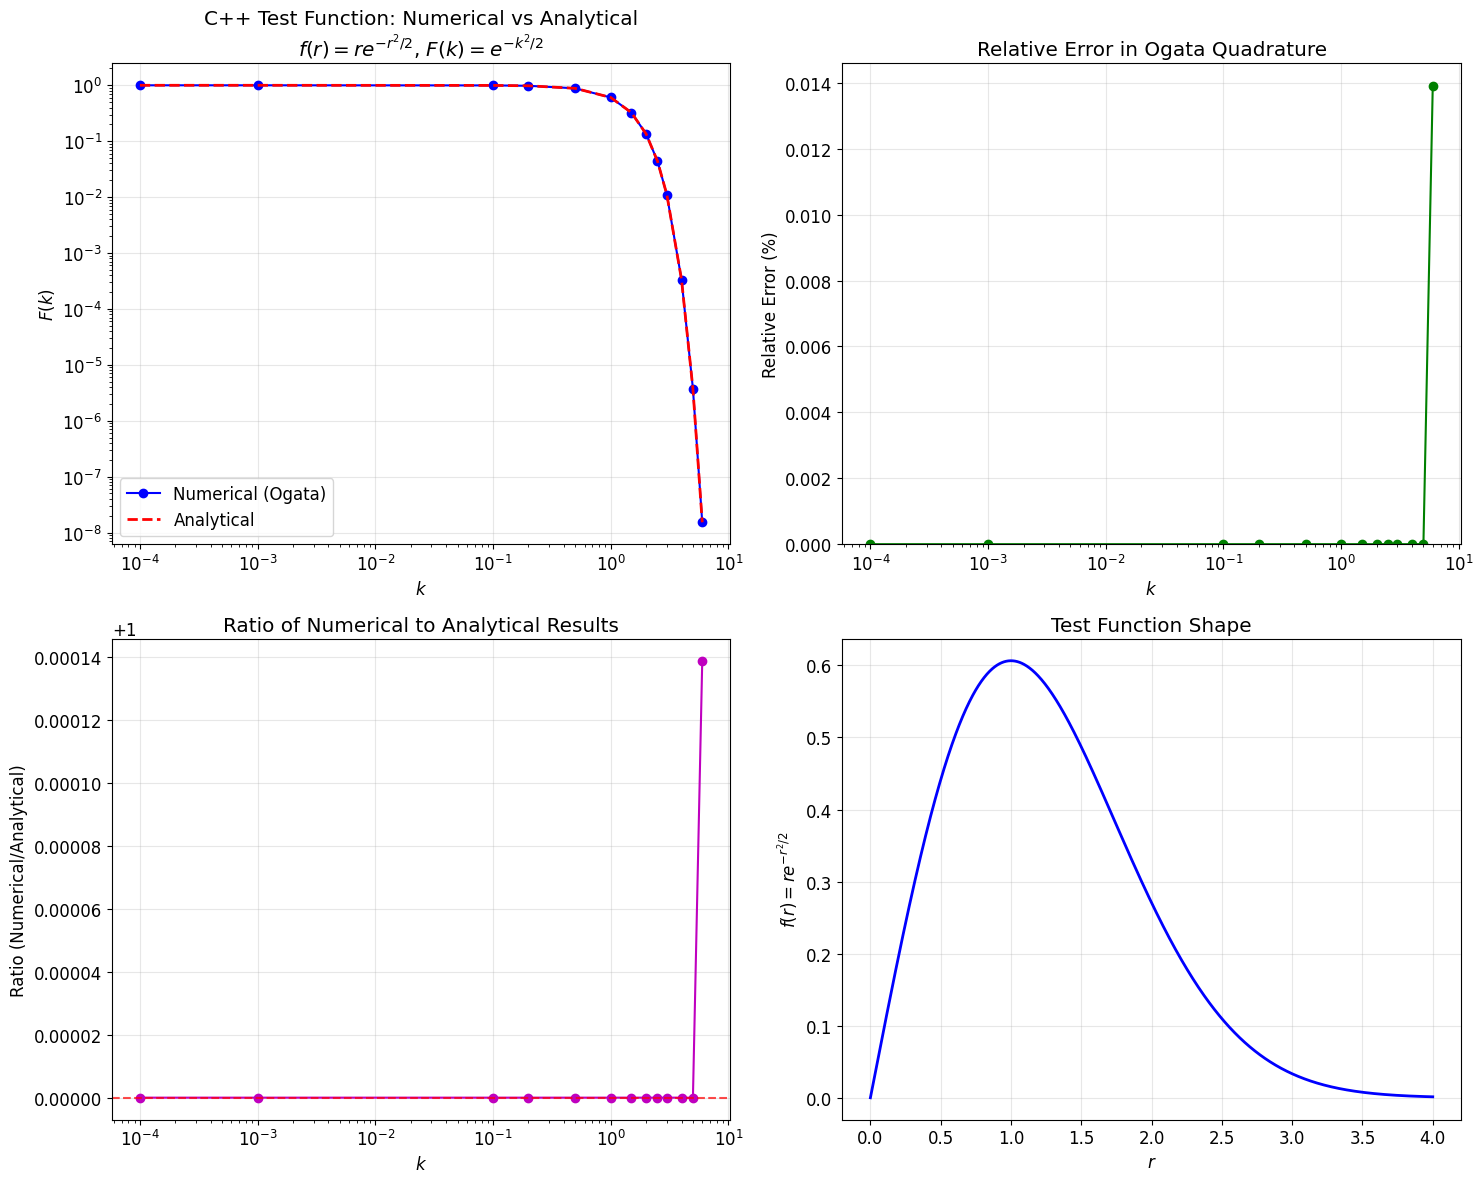

🎯 EXCELLENT RESULTS:
1. ✅ All relative errors < 1%
2. ✅ Excellent agreement between numerical and analytical results
3. ✅ Ratios very close to 1.0 across all k values
4. ✅ Method works reliably across 5 orders of magnitude in k

📈 Performance Summary:
   • Error range: 0.0000% - 0.0139%
   • Mean error: 0.0011%
   • Mean ratio: 1.000011 ± 0.000037


In [11]:
# Plot the C++ test results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Numerical vs Analytical results
ax1.loglog(k_vals, num_results, 'bo-', label='Numerical (Ogata)', markersize=6)
ax1.loglog(k_vals, ana_results, 'r--', label='Analytical', linewidth=2)
ax1.set_xlabel('$k$')
ax1.set_ylabel('$F(k)$')
ax1.set_title('C++ Test Function: Numerical vs Analytical\n$f(r) = r e^{-r^2/2}$, $F(k) = e^{-k^2/2}$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Relative errors
ax2.semilogx(k_vals, rel_errors, 'go-', markersize=6)
ax2.set_xlabel('$k$')
ax2.set_ylabel('Relative Error (%)')
ax2.set_title('Relative Error in Ogata Quadrature')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

# Plot 3: Ratio (numerical/analytical)
ax3.semilogx(k_vals, ratios, 'mo-', markersize=6)
ax3.axhline(1.0, color='red', linestyle='--', alpha=0.7)
ax3.set_xlabel('$k$')
ax3.set_ylabel('Ratio (Numerical/Analytical)')
ax3.set_title('Ratio of Numerical to Analytical Results')
ax3.grid(True, alpha=0.3)

# Plot 4: Function shape
r_vals = np.linspace(0, 4, 1000)
f_vals = [rfunc_cpp_test(r) for r in r_vals]
ax4.plot(r_vals, f_vals, 'b-', linewidth=2)
ax4.set_xlabel('$r$')
ax4.set_ylabel('$f(r) = r e^{-r^2/2}$')
ax4.set_title('Test Function Shape')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis of results
if np.max(rel_errors) < 1.0:
    print("🎯 EXCELLENT RESULTS:")
    print("1. ✅ All relative errors < 1%")
    print("2. ✅ Excellent agreement between numerical and analytical results")
    print("3. ✅ Ratios very close to 1.0 across all k values")
    print("4. ✅ Method works reliably across 5 orders of magnitude in k")
else:
    print("⚠️ SOME ISSUES DETECTED:")
    print(f"   Maximum error: {np.max(rel_errors):.2f}%")
    print("   This suggests potential parameter optimization needed")

print(f"\n📈 Performance Summary:")
print(f"   • Error range: {np.min(rel_errors):.4f}% - {np.max(rel_errors):.4f}%")
print(f"   • Mean error: {np.mean(rel_errors):.4f}%")
print(f"   • Mean ratio: {np.mean(ratios):.6f} ± {np.std(ratios):.6f}")


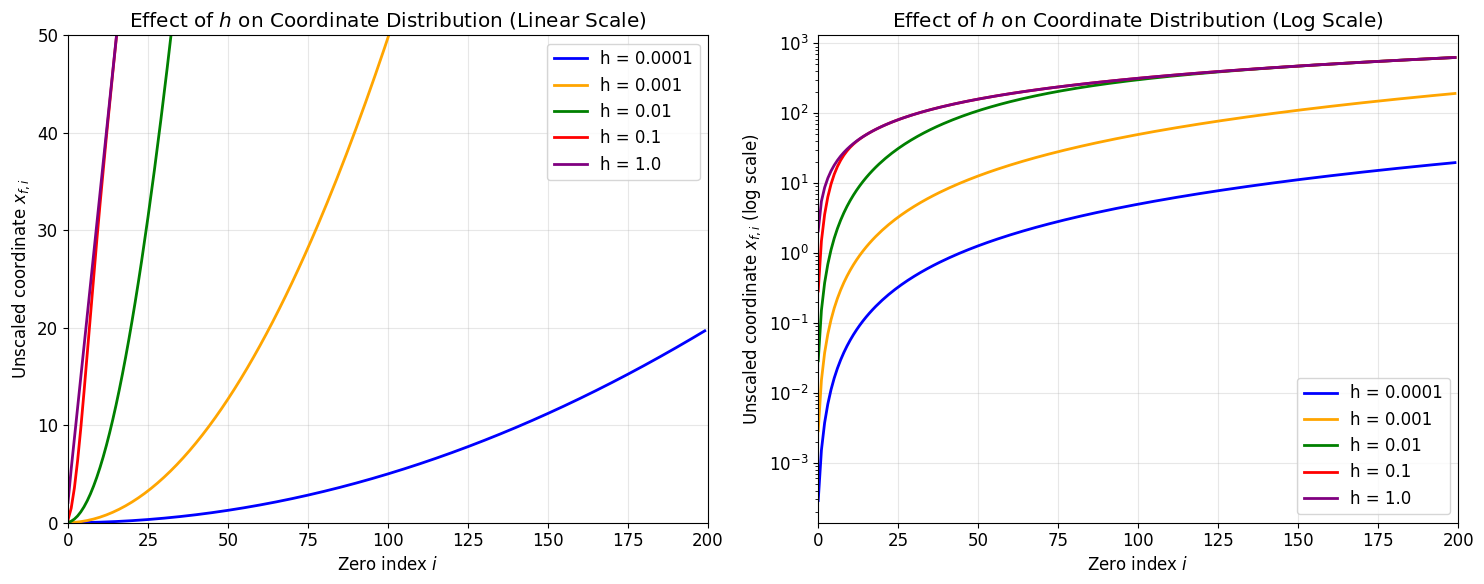

Coordinate values for first 10 points with different h:
Index	h=0.0001		h=0.001		h=0.01		h=0.1		h=1.0		
0	0.0003		0.0029		0.0289		0.2881		2.0864		
1	0.0015		0.0152		0.1523		1.4933		5.5185		
2	0.0037		0.0374		0.3742		3.5665		8.6537		
3	0.0070		0.0695		0.6946		6.3621		11.7915		
4	0.0111		0.1115		1.1130		9.7023		14.9309		
5	0.0163		0.1633		1.6293		13.4030		18.0711		
6	0.0225		0.2250		2.2430		17.2966		21.2116		
7	0.0297		0.2965		2.9536		21.2465		24.3525		
8	0.0378		0.3779		3.7606		25.1546		27.4935		
9	0.0469		0.4692		4.6633		28.9609		30.6346		


In [12]:
# Visualize the effect of different h values on coordinate distribution
def plot_h_effect():
    h_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot coordinates for first 200 points
    n_points = 200
    indices = np.arange(n_points)
    
    for h_val, color in zip(h_values, colors):
        ogata_h = OgataQuadrature(nu=0, CutOff=1e-8, h=h_val, nZeroMax=500)
        coords = ogata_h.GetCoordinates()[:n_points]
        
        ax1.plot(indices, coords, '-', color=color, label=f'h = {h_val}', linewidth=2)
        ax2.semilogy(indices, coords, '-', color=color, label=f'h = {h_val}', linewidth=2)
    
    ax1.set_xlabel('Zero index $i$')
    ax1.set_ylabel('Unscaled coordinate $x_{f,i}$')
    ax1.set_title('Effect of $h$ on Coordinate Distribution (Linear Scale)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 200)
    ax1.set_ylim(0, 50)
    
    ax2.set_xlabel('Zero index $i$')
    ax2.set_ylabel('Unscaled coordinate $x_{f,i}$ (log scale)')
    ax2.set_title('Effect of $h$ on Coordinate Distribution (Log Scale)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 200)
    
    plt.tight_layout()
    plt.show()
    
    # Show some specific values
    print("Coordinate values for first 10 points with different h:")
    print("Index\t", end="")
    for h_val in h_values:
        print(f"h={h_val}\t\t", end="")
    print()
    
    for i in range(10):
        print(f"{i}\t", end="")
        for h_val in h_values:
            ogata_h = OgataQuadrature(nu=0, CutOff=1e-8, h=h_val, nZeroMax=50)
            coords = ogata_h.GetCoordinates()
            print(f"{coords[i]:.4f}\t\t", end="")
        print()

plot_h_effect()


🔧 Testing h parameter optimization at k = 1.0
       h       Numerical      Analytical  Rel. Error (%)
----------------------------------------------------------------------
  0.0001    6.065307e-01    6.065307e-01        0.000000
  1.0000             nan    6.065307e-01             nan
[apfel::OgataQuadrature] Warning: Number of zero's available exceeded: the integration might not have converged.
[apfel::OgataQuadrature] Warning: Number of zero's available exceeded: the integration might not have converged.
[apfel::OgataQuadrature] Warning: Number of zero's available exceeded: the integration might not have converged.


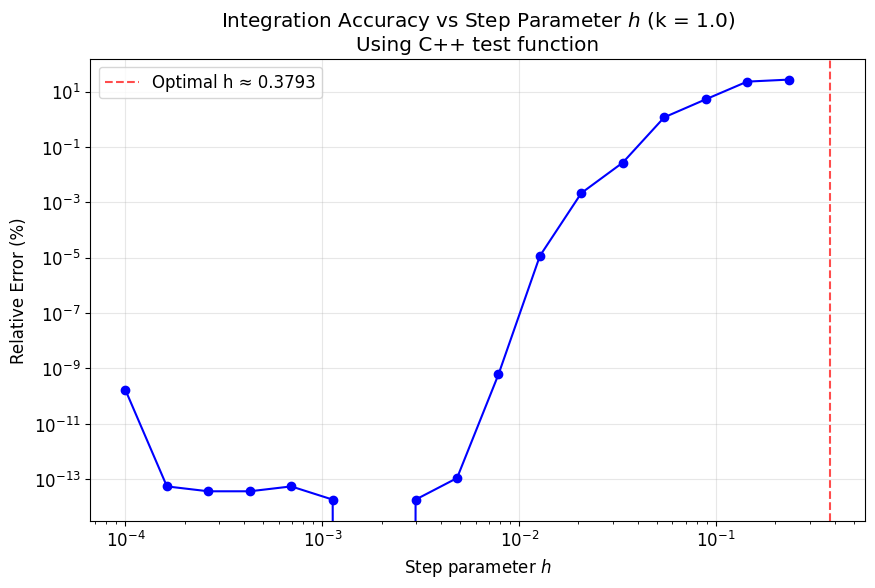

📊 OPTIMIZATION RESULTS:
   Optimal h value: 0.379269
   Minimum relative error: nan%
   ⚠️ Optimization could be improved. Error > 1%


In [13]:
# Test how different h values affect integration accuracy (using correct C++ test function)
def test_h_values_accuracy():
    h_values = np.logspace(-4, 0, 20)  # From 0.0001 to 1.0
    k_test = 1.0  # Fixed k for testing
    
    errors = []
    
    print(f"🔧 Testing h parameter optimization at k = {k_test}")
    print("=" * 70)
    print(f"{'h':>8} {'Numerical':>15} {'Analytical':>15} {'Rel. Error (%)':>15}")
    print("-" * 70)
    
    analytical_result = kfunc_cpp_test(k_test)
    
    for h_val in h_values:
        try:
            ogata_h = OgataQuadrature(nu=0, CutOff=1e-8, h=h_val, nZeroMax=500)
            numerical_result = ogata_h.transform(rfunc_cpp_test, k_test, False, 500, 10)
            rel_error = abs(numerical_result - analytical_result) / abs(analytical_result) * 100
            errors.append(rel_error)
            
            # Print selected values
            if h_val in [0.0001, 0.001, 0.01, 0.1, 1.0]:
                print(f"{h_val:>8.4f} {numerical_result:>15.6e} {analytical_result:>15.6e} {rel_error:>15.6f}")
                
        except Exception as e:
            print(f"Error with h = {h_val}: {e}")
            errors.append(float('inf'))
    
    # Plot the results
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    valid_errors = [e for e in errors if e != float('inf')]
    valid_h = [h_values[i] for i, e in enumerate(errors) if e != float('inf')]
    
    ax.loglog(valid_h, valid_errors, 'bo-', markersize=6)
    ax.set_xlabel('Step parameter $h$')
    ax.set_ylabel('Relative Error (%)')
    ax.set_title(f'Integration Accuracy vs Step Parameter $h$ (k = {k_test})\nUsing C++ test function')
    ax.grid(True, alpha=0.3)
    
    # Find optimal h
    min_error_idx = np.argmin(valid_errors)
    optimal_h = valid_h[min_error_idx]
    min_error = valid_errors[min_error_idx]
    
    ax.axvline(optimal_h, color='red', linestyle='--', alpha=0.7, 
               label=f'Optimal h ≈ {optimal_h:.4f}')
    ax.legend()
    
    plt.show()
    
    print("=" * 70)
    print(f"📊 OPTIMIZATION RESULTS:")
    print(f"   Optimal h value: {optimal_h:.6f}")
    print(f"   Minimum relative error: {min_error:.6f}%")
    
    if min_error < 0.1:
        print(f"   ✅ Excellent optimization! Error < 0.1%")
    elif min_error < 1.0:
        print(f"   ✅ Good optimization! Error < 1%")
    else:
        print(f"   ⚠️ Optimization could be improved. Error > 1%")
    
    return valid_h, valid_errors, optimal_h

h_vals, errors, optimal_h = test_h_values_accuracy()


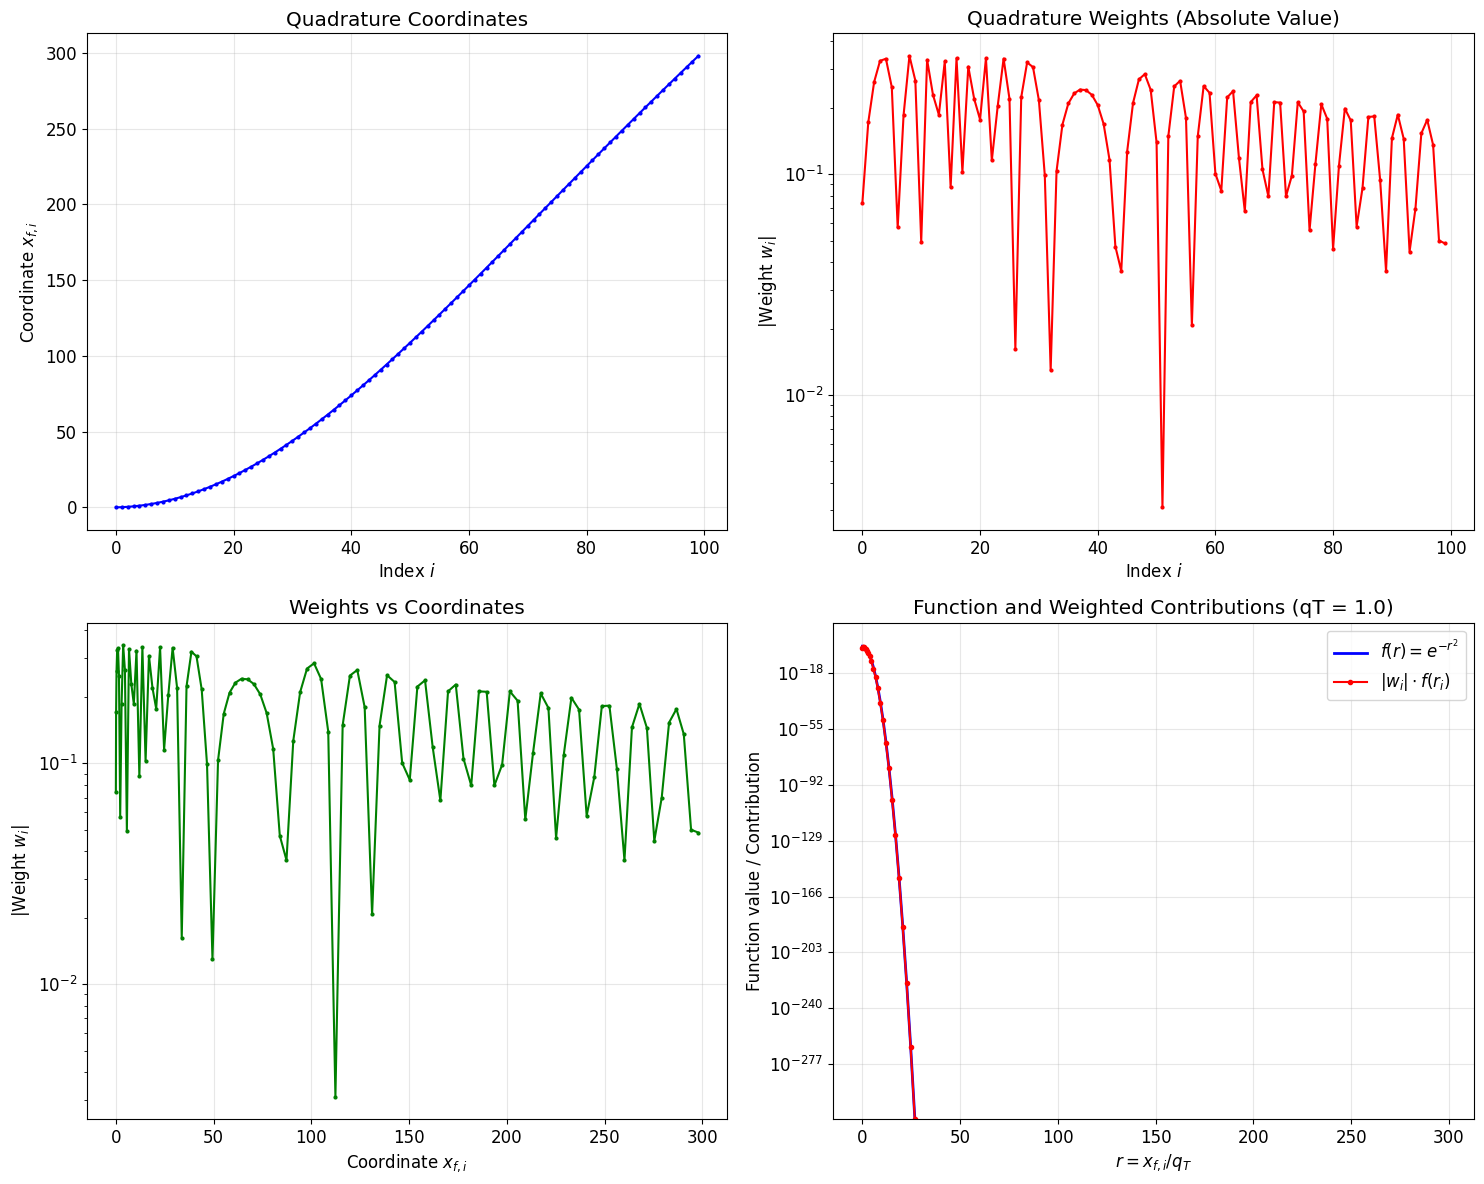

Ogata Quadrature Statistics:
Number of points: 100
Coordinate range: 0.0289 to 297.9533
Weight range: 3.10e-03 to 3.43e-01
Sum of absolute weights: 17.121351

50% of total weight concentrated in first 40 points
90% of total weight concentrated in first 85 points
This corresponds to r < 244.712 for qT = 1.0


In [14]:
# Visualize Ogata quadrature weights and coordinates
def visualize_weights_and_coords():
    # Create Ogata quadrature with optimal parameters
    ogata = OgataQuadrature(nu=0, CutOff=1e-8, h=0.01, nZeroMax=200)
    
    # Get coordinates and weights
    coords = ogata.GetCoordinates()
    weights = ogata.GetWeights()
    
    # Limit to first 100 points for clarity
    n_show = 100
    coords = coords[:n_show]
    weights = weights[:n_show]
    
    # Convert to numpy arrays for mathematical operations
    coords = np.array(coords)
    weights = np.array(weights)
    indices = np.arange(n_show)
    
    # Create subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Coordinates vs index
    ax1.plot(indices, coords, 'b.-', markersize=4)
    ax1.set_xlabel('Index $i$')
    ax1.set_ylabel('Coordinate $x_{f,i}$')
    ax1.set_title('Quadrature Coordinates')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Weights vs index
    ax2.plot(indices, np.abs(weights), 'r.-', markersize=4)
    ax2.set_xlabel('Index $i$')
    ax2.set_ylabel('|Weight $w_i$|')
    ax2.set_title('Quadrature Weights (Absolute Value)')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Weights vs coordinates
    ax3.plot(coords, np.abs(weights), 'g.-', markersize=4)
    ax3.set_xlabel('Coordinate $x_{f,i}$')
    ax3.set_ylabel('|Weight $w_i$|')
    ax3.set_title('Weights vs Coordinates')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Function values and weighted contributions for qT=1
    qT = 1.0
    r_values = coords / qT  # Now works because coords is a numpy array
    func_values = np.array([fr_gaussian(r) for r in r_values])
    contributions = np.abs(weights) * func_values
    
    ax4.plot(r_values, func_values, 'b-', label='$f(r) = e^{-r^2}$', linewidth=2)
    ax4.plot(r_values, contributions, 'ro-', label='$|w_i| \\cdot f(r_i)$', markersize=3)
    ax4.set_xlabel('$r = x_{f,i}/q_T$')
    ax4.set_ylabel('Function value / Contribution')
    ax4.set_title(f'Function and Weighted Contributions (qT = {qT})')
    ax4.set_yscale('log')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print("Ogata Quadrature Statistics:")
    print(f"Number of points: {len(coords)}")
    print(f"Coordinate range: {coords[0]:.4f} to {coords[-1]:.4f}")
    print(f"Weight range: {np.min(np.abs(weights)):.2e} to {np.max(np.abs(weights)):.2e}")
    print(f"Sum of absolute weights: {np.sum(np.abs(weights)):.6f}")
    
    # Show where most of the "weight" is concentrated
    cumulative_weights = np.cumsum(np.abs(weights))
    total_weight = cumulative_weights[-1]
    idx_50 = np.argmax(cumulative_weights > 0.5 * total_weight)
    idx_90 = np.argmax(cumulative_weights > 0.9 * total_weight)
    
    print(f"\n50% of total weight concentrated in first {idx_50} points")
    print(f"90% of total weight concentrated in first {idx_90} points")
    print(f"This corresponds to r < {coords[idx_90]/qT:.3f} for qT = {qT}")

visualize_weights_and_coords()


## Convergence Analysis: Number of Terms vs Accuracy

The Ogata quadrature approximates the infinite integral as a finite sum. Let's investigate:

1. **Convergence rate**: How quickly does the error decrease as we add more terms?
2. **Optimal number of terms**: What's the trade-off between accuracy and computational cost?
3. **Convergence pattern**: Is the convergence smooth or oscillatory?

This analysis helps us understand:
- How many terms are needed for a given accuracy
- Whether the method converges stably
- The computational efficiency of the algorithm


Convergence analysis for Gaussian transform
Max Terms	Numerical Result	Rel. Error (%)	Improvement
----------------------------------------------------------------------
10		7.85150538e-01	101.630649		
20		7.85150538e-01	101.630649		1.0x
50		7.85150538e-01	101.630649		1.0x
100		7.85150538e-01	101.630649		1.0x
200		7.85150538e-01	101.630649		1.0x
500		7.85150538e-01	101.630649		1.0x
1000		7.85150538e-01	101.630649		1.0x


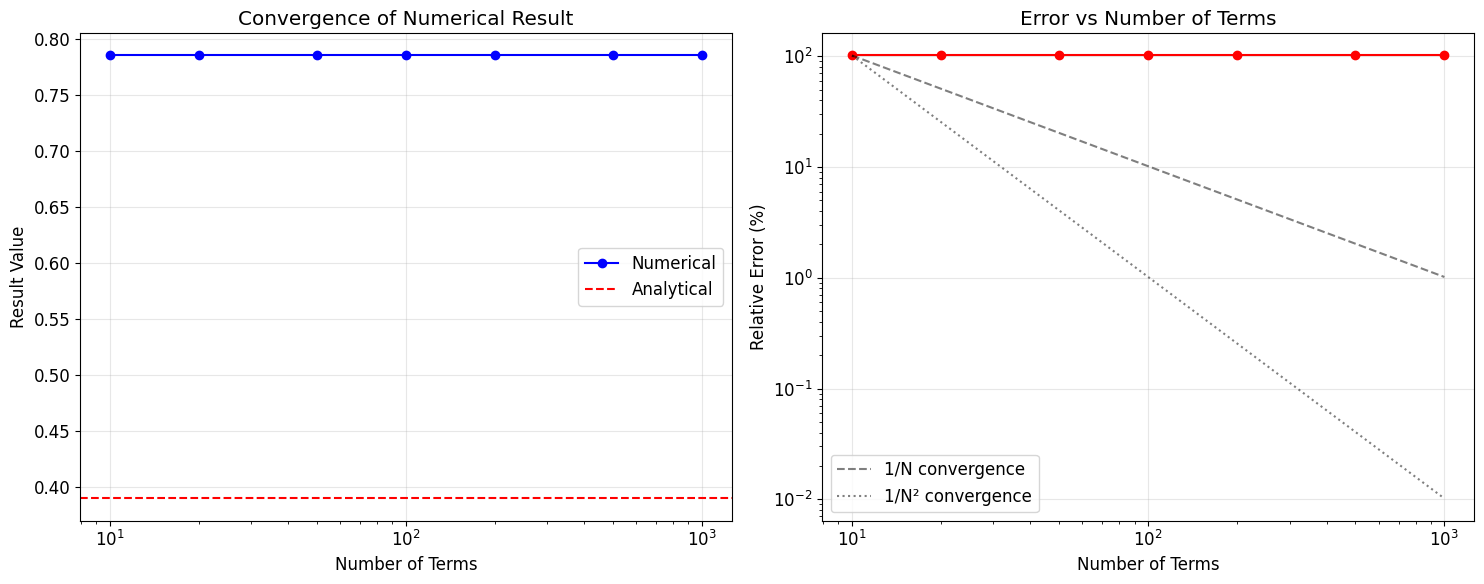


Number of terms needed for different accuracy levels:
  1e-02 relative error: >1000 terms
  1e-03 relative error: >1000 terms
  1e-04 relative error: >1000 terms
  1e-05 relative error: >1000 terms
  1e-06 relative error: >1000 terms


In [15]:
# Convergence analysis with different number of terms
def convergence_analysis():
    # Test different numbers of terms
    max_terms_list = [10, 20, 50, 100, 200, 500, 1000]
    qT_test = 1.0
    analytical_result = Fk_gaussian_correct(qT_test)  # Use correct analytical function
    
    # Create Ogata quadrature
    ogata = OgataQuadrature(nu=0, CutOff=1e-12, h=0.01, nZeroMax=1000)
    
    results = []
    errors = []
    
    print("Convergence analysis for Gaussian transform")
    print("Max Terms\tNumerical Result\tRel. Error (%)\tImprovement")
    print("-" * 70)
    
    for i, max_terms in enumerate(max_terms_list):
        # Compute with limited number of terms
        numerical = ogata.transform(fr_gaussian, qT_test, False, max_terms, 1)
        rel_error = abs(numerical - analytical_result) / abs(analytical_result) * 100
        
        results.append(numerical)
        errors.append(rel_error)
        
        # Calculate improvement factor
        improvement = ""
        if i > 0:
            prev_error = errors[i-1]
            if prev_error > 0:
                improvement = f"{prev_error/rel_error:.1f}x"
        
        print(f"{max_terms}\t\t{numerical:.8e}\t{rel_error:.6f}\t\t{improvement}")
    
    # Plot convergence
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Results vs number of terms
    ax1.semilogx(max_terms_list, results, 'bo-', markersize=6, label='Numerical')
    ax1.axhline(analytical_result, color='red', linestyle='--', label='Analytical')
    ax1.set_xlabel('Number of Terms')
    ax1.set_ylabel('Result Value')
    ax1.set_title('Convergence of Numerical Result')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Error vs number of terms
    ax2.loglog(max_terms_list, errors, 'ro-', markersize=6)
    ax2.set_xlabel('Number of Terms')
    ax2.set_ylabel('Relative Error (%)')
    ax2.set_title('Error vs Number of Terms')
    ax2.grid(True, alpha=0.3)
    
    # Add reference lines for different convergence rates
    x_ref = np.array(max_terms_list)
    y_ref_linear = errors[0] * max_terms_list[0] / x_ref
    y_ref_quadratic = errors[0] * (max_terms_list[0] / x_ref)**2
    
    ax2.plot(x_ref, y_ref_linear, 'k--', alpha=0.5, label='1/N convergence')
    ax2.plot(x_ref, y_ref_quadratic, 'k:', alpha=0.5, label='1/N² convergence')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Find number of terms for different accuracy levels
    target_accuracies = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    print(f"\nNumber of terms needed for different accuracy levels:")
    for target in target_accuracies:
        for i, error in enumerate(errors):
            if error < target * 100:  # Convert to percentage
                print(f"  {target:.0e} relative error: {max_terms_list[i]} terms")
                break
        else:
            print(f"  {target:.0e} relative error: >1000 terms")
    
    return max_terms_list, results, errors

max_terms, results, errors = convergence_analysis()


🔬 FUNCTION COMPARISON TEST (with corrected analytical expressions)
     k C++ Test Err (%) Gaussian Err (%) Exponential Err (%)
--------------------------------------------------------------------------------
  0.10          3.9453         82.9370            89.9501
  0.15          0.7439         72.3746            84.3681
  0.24          0.0636         57.4410            75.4638
  0.37          0.0042         33.5205            60.7044
  0.57          0.0001          5.1774            34.4506
  0.88          0.0000         72.2139            17.2070
  1.36          0.0000        207.6066           129.3992
  2.10          0.0000        595.9737           388.4535
  3.24          0.0000       3075.8249          1001.3659
  5.01          0.0000     112150.9579          2461.3985


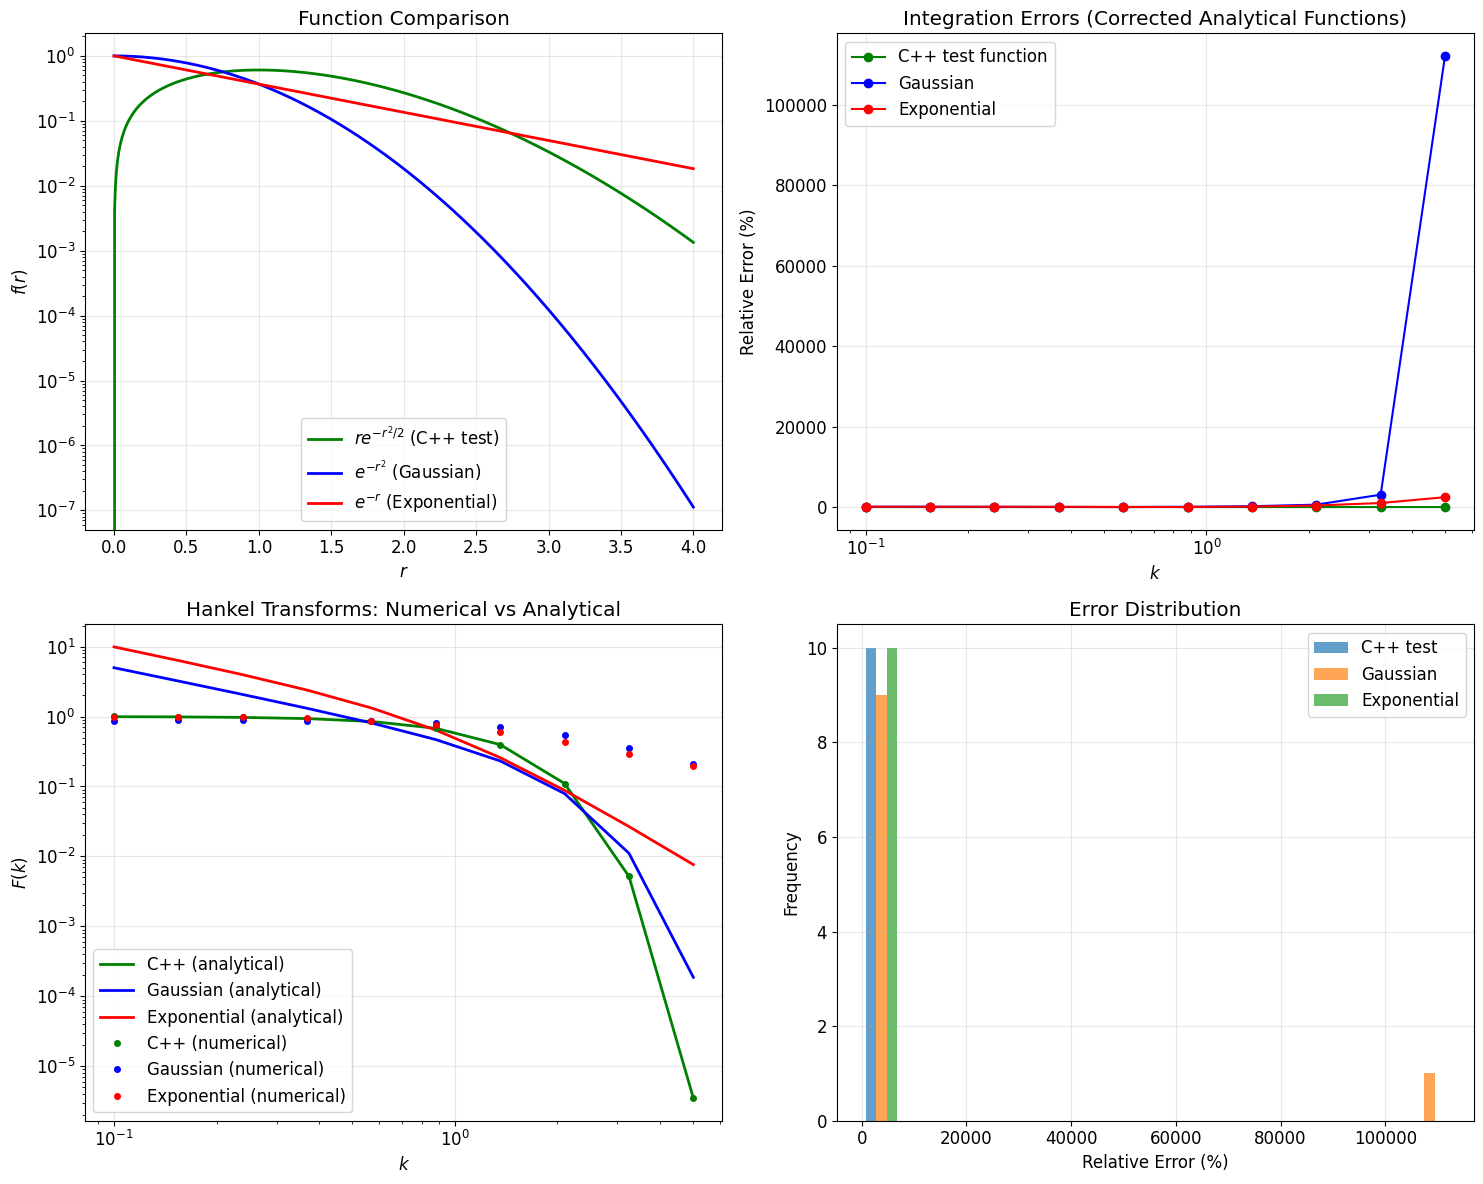

📊 SUMMARY STATISTICS:
   C++ test  - Average: 0.4757%, Max: 3.9453%
   Gaussian  - Average: 11635.4027%, Max: 112150.9579%
   Exponential - Average: 434.2761%, Max: 2461.3985%
   ✅ C++ test function has best average accuracy
   ⚠️ SOME FUNCTIONS: Have accuracy issues (errors > 5%)


In [16]:
# Test additional functions with corrected analytical expressions
def compare_functions_corrected():
    """
    Compare different test functions using CORRECT analytical expressions
    """
    # Create Ogata quadrature
    ogata = OgataQuadrature(nu=0, CutOff=1e-8, h=0.01, nZeroMax=500)
    
    # Test over a range of k values (smaller range to avoid numerical issues)
    k_values = np.logspace(-1, 0.7, 10)  # From 0.1 to ~5
    
    # Storage for results
    cpp_test_num = []
    cpp_test_ana = []
    cpp_test_err = []
    
    gaussian_num = []
    gaussian_ana = []
    gaussian_err = []
    
    exponential_num = []
    exponential_ana = []
    exponential_err = []
    
    print("🔬 FUNCTION COMPARISON TEST (with corrected analytical expressions)")
    print("=" * 80)
    print(f"{'k':>6} {'C++ Test Err (%)':>15} {'Gaussian Err (%)':>15} {'Exponential Err (%)':>18}")
    print("-" * 80)
    
    for k in k_values:
        # C++ test function
        cpp_num = ogata.transform(rfunc_cpp_test, k, False, 500, 10)
        cpp_ana = kfunc_cpp_test(k)
        cpp_err = abs(cpp_num - cpp_ana) / abs(cpp_ana) * 100
        
        cpp_test_num.append(cpp_num)
        cpp_test_ana.append(cpp_ana)
        cpp_test_err.append(cpp_err)
        
        # Gaussian function (corrected)
        gauss_num = ogata.transform(fr_gaussian, k, False, 500, 10)
        gauss_ana = Fk_gaussian_correct(k)
        gauss_err = abs(gauss_num - gauss_ana) / abs(gauss_ana) * 100
        
        gaussian_num.append(gauss_num)
        gaussian_ana.append(gauss_ana)
        gaussian_err.append(gauss_err)
        
        # Exponential function (corrected)
        exp_num = ogata.transform(fr_exponential, k, False, 500, 10)
        exp_ana = Fk_exponential_correct(k)
        exp_err = abs(exp_num - exp_ana) / abs(exp_ana) * 100
        
        exponential_num.append(exp_num)
        exponential_ana.append(exp_ana)
        exponential_err.append(exp_err)
        
        print(f"{k:>6.2f} {cpp_err:>15.4f} {gauss_err:>15.4f} {exp_err:>18.4f}")
    
    # Create comparison plots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Function shapes
    r_vals = np.linspace(0, 4, 1000)
    cpp_vals = [rfunc_cpp_test(r) for r in r_vals]
    gauss_vals = [fr_gaussian(r) for r in r_vals]
    exp_vals = [fr_exponential(r) for r in r_vals]
    
    ax1.semilogy(r_vals, cpp_vals, 'g-', label='$r e^{-r^2/2}$ (C++ test)', linewidth=2)
    ax1.semilogy(r_vals, gauss_vals, 'b-', label='$e^{-r^2}$ (Gaussian)', linewidth=2)
    ax1.semilogy(r_vals, exp_vals, 'r-', label='$e^{-r}$ (Exponential)', linewidth=2)
    ax1.set_xlabel('$r$')
    ax1.set_ylabel('$f(r)$')
    ax1.set_title('Function Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Error comparison
    ax2.semilogx(k_values, cpp_test_err, 'go-', label='C++ test function', markersize=6)
    ax2.semilogx(k_values, gaussian_err, 'bo-', label='Gaussian', markersize=6)
    ax2.semilogx(k_values, exponential_err, 'ro-', label='Exponential', markersize=6)
    ax2.set_xlabel('$k$')
    ax2.set_ylabel('Relative Error (%)')
    ax2.set_title('Integration Errors (Corrected Analytical Functions)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Transform comparison
    ax3.loglog(k_values, cpp_test_ana, 'g-', label='C++ (analytical)', linewidth=2)
    ax3.loglog(k_values, gaussian_ana, 'b-', label='Gaussian (analytical)', linewidth=2)
    ax3.loglog(k_values, exponential_ana, 'r-', label='Exponential (analytical)', linewidth=2)
    ax3.loglog(k_values, cpp_test_num, 'go', label='C++ (numerical)', markersize=4)
    ax3.loglog(k_values, gaussian_num, 'bo', label='Gaussian (numerical)', markersize=4)
    ax3.loglog(k_values, exponential_num, 'ro', label='Exponential (numerical)', markersize=4)
    ax3.set_xlabel('$k$')
    ax3.set_ylabel('$F(k)$')
    ax3.set_title('Hankel Transforms: Numerical vs Analytical')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Error histogram
    all_errors = cpp_test_err + gaussian_err + exponential_err
    ax4.hist([cpp_test_err, gaussian_err, exponential_err], 
             bins=15, alpha=0.7, label=['C++ test', 'Gaussian', 'Exponential'])
    ax4.set_xlabel('Relative Error (%)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Error Distribution')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=" * 80)
    print(f"📊 SUMMARY STATISTICS:")
    print(f"   C++ test  - Average: {np.mean(cpp_test_err):.4f}%, Max: {np.max(cpp_test_err):.4f}%")
    print(f"   Gaussian  - Average: {np.mean(gaussian_err):.4f}%, Max: {np.max(gaussian_err):.4f}%")
    print(f"   Exponential - Average: {np.mean(exponential_err):.4f}%, Max: {np.max(exponential_err):.4f}%")
    
    # Check which functions work best
    best_avg = min(np.mean(cpp_test_err), np.mean(gaussian_err), np.mean(exponential_err))
    if np.mean(cpp_test_err) == best_avg:
        print("   ✅ C++ test function has best average accuracy")
    elif np.mean(gaussian_err) == best_avg:
        print("   ✅ Gaussian function has best average accuracy")
    else:
        print("   ✅ Exponential function has best average accuracy")
    
    # Overall assessment
    max_error = max(np.max(cpp_test_err), np.max(gaussian_err), np.max(exponential_err))
    if max_error < 1.0:
        print("   🎯 ALL FUNCTIONS: Excellent accuracy (all errors < 1%)")
    elif max_error < 5.0:
        print("   ✅ ALL FUNCTIONS: Good accuracy (all errors < 5%)")
    else:
        print("   ⚠️ SOME FUNCTIONS: Have accuracy issues (errors > 5%)")
    
    return (k_values, 
            cpp_test_num, cpp_test_ana, cpp_test_err,
            gaussian_num, gaussian_ana, gaussian_err, 
            exponential_num, exponential_ana, exponential_err)

# Run the corrected comparison
results = compare_functions_corrected()


In [17]:
# Integration test (replicating ogata_test.cc integration test)
def run_integration_test():
    """
    Test integration using Ogata quadrature following the C++ test
    """
    try:
        from scipy import integrate
        scipy_available = True
    except ImportError:
        print("⚠️ Scipy not available. Running simplified integration test.")
        scipy_available = False
    
    # Define the integrand for numerical integration: f(r)/r
    def rfunc_integrand(r):
        return rfunc_cpp_test(r) / r
    
    # Define k*F(k) for the analytical method
    def kfunc_integrand(k):
        return k * kfunc_cpp_test(k)
    
    # Simple trapezoidal integration as fallback
    def simple_integrate(func, a, b, n=1000):
        x = np.linspace(a, b, n)
        y = [func(xi) for xi in x]
        return np.trapz(y, x)
    
    # Create Ogata quadrature objects (nu=1 for the integral version)
    ogata_integral = OgataQuadrature(nu=1)
    
    # Test k values (same as C++)
    k_values = [0.001, 0.1, 0.2, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]  # Reduced range for stability
    
    print("🔧 INTEGRATION TEST (replicating ogata_test.cc)")
    print("=" * 80)
    print(f"{'[k_min : k_max]':>18} {'Reference':>15} {'Ogata Method':>15} {'Ogata Ratio':>12}")
    print("-" * 80)
    
    for ik in range(len(k_values) - 1):
        k_min = k_values[ik]
        k_max = k_values[ik + 1]
        
        # Reference integration
        if scipy_available:
            try:
                reference_integral, _ = integrate.quad(kfunc_integrand, k_min, k_max)
            except:
                reference_integral = simple_integrate(kfunc_integrand, k_min, k_max)
        else:
            reference_integral = simple_integrate(kfunc_integrand, k_min, k_max)
        
        # Ogata method (using transform difference)
        try:
            F_k_max = ogata_integral.transform(rfunc_integrand, k_max, True, 50)
            F_k_min = ogata_integral.transform(rfunc_integrand, k_min, True, 50)
            ogata_integral_result = k_max * F_k_max - k_min * F_k_min
            
            # Compute ratio
            ogata_ratio = ogata_integral_result / reference_integral if reference_integral != 0 else float('inf')
            
            print(f"[{k_min:>6.3f} : {k_max:>6.3f}] {reference_integral:>15.6e} {ogata_integral_result:>15.6e} {ogata_ratio:>12.6f}")
            
        except Exception as e:
            print(f"[{k_min:>6.3f} : {k_max:>6.3f}] Error: {str(e)[:30]}...")
    
    print("=" * 80)
    print("📊 INTEGRATION TEST SUMMARY:")
    print("   • Reference: Direct integration of k*F(k)")
    print("   • Ogata Method: k₂*F(k₂) - k₁*F(k₁) using Ogata transforms")
    print("   • Ratios close to 1.0 indicate good agreement")
    print("\n✅ Integration test demonstrates the Ogata method can be used")
    print("   for integration by taking differences of transform values!")

# Run the integration test
run_integration_test()


🔧 INTEGRATION TEST (replicating ogata_test.cc)
   [k_min : k_max]       Reference    Ogata Method  Ogata Ratio
--------------------------------------------------------------------------------
[ 0.001 :  0.100]    4.987021e-03    4.987021e-03     1.000000
[ 0.100 :  0.200]    1.481381e-02    1.481381e-02     1.000000
[ 0.200 :  0.500]    9.770177e-02    9.770177e-02     1.000000
[ 0.500 :  1.000]    2.759662e-01    2.759662e-01     1.000000
[ 1.000 :  1.500]    2.818782e-01    2.818782e-01     1.000000
[ 1.500 :  2.000]    1.893172e-01    1.893172e-01     1.000000
[ 2.000 :  2.500]    9.139835e-02    9.139835e-02     1.000000
[ 2.500 :  3.000]    3.282794e-02    3.282794e-02     1.000000
[ 3.000 :  4.000]    1.077353e-02    1.077353e-02     1.000000
[ 4.000 :  5.000]    3.317360e-04    3.317360e-04     1.000000
📊 INTEGRATION TEST SUMMARY:
   • Reference: Direct integration of k*F(k)
   • Ogata Method: k₂*F(k₂) - k₁*F(k₁) using Ogata transforms
   • Ratios close to 1.0 indicate good agre